In [1]:
## importing all the packages
import time
import psutil
import json
import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)


In [2]:
# Reading the csv

df = pd.read_csv(r"cleaned_merged_heart_dataset.csv")
print("Shape: ", df.shape)

df_duplicates = df.duplicated().sum()
print("Duplicates: ", df_duplicates)

df = df.drop_duplicates().reset_index(drop=True)
print("After deleting the duplicates: ",df.shape)

# Splitting features (X) from the target (y)
X = df.drop(columns=["target"])
y = df["target"]
y.value_counts()


Shape:  (1888, 14)
Duplicates:  1286
After deleting the duplicates:  (602, 14)


target
0    310
1    292
Name: count, dtype: int64

In [3]:
# Splitting into training and testing datasets

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print("Train size: ", X_train.shape[0], "Test size: ", X_test.shape[0])

# Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train size:  451 Test size:  151


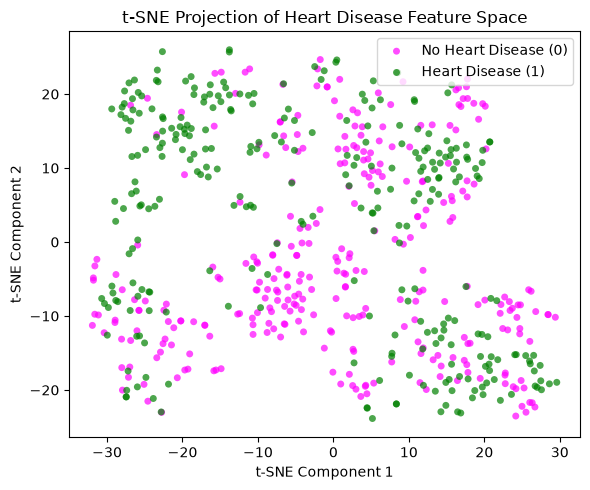

In [4]:
# Separate scaler just for the visualization
scaler_visualisation = StandardScaler()
X_scaled_full = scaler_visualisation.fit_transform(X)

# TSNE
tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_scaled_full)

# To plot it and save it as a graph
plt.figure(figsize=(6, 5))

for label, color, name in [(0, "#FF00FF", "No Heart Disease (0)"),
                           (1, "#008000", "Heart Disease (1)")]:
    mask = y == label
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=color, label=name,
                alpha=0.7, s=25, edgecolors="none")

plt.title("t-SNE Projection of Heart Disease Feature Space")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.tight_layout()
plt.savefig("tsne_plot.png", dpi=300)
plt.show()

In [5]:
# Support Vector Machine

svm_kernels = ["linear", "poly", "rbf"]

for kernel in svm_kernels:
    model = SVC(kernel=kernel, random_state=RANDOM_STATE)

# Decision Tree

for depth in [2, 5, 10, None]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)

for split in [10, 50]:
    model = DecisionTreeClassifier(min_samples_split=split, random_state=RANDOM_STATE)

In [6]:
# Metrics calculation for SVM

# Helper: trains a model and measures wall time, CPU time and memory used
def measure_fit(model, X, y, repeats=20):
    process = psutil.Process()
    mem_before = process.memory_info().rss / 1024**2      # memory in MB

    cpu_start = time.process_time()
    wall_start = time.perf_counter()
    for _ in range(repeats):
        model.fit(X, y)
    wall_time = (time.perf_counter() - wall_start) / repeats
    cpu_time = (time.process_time() - cpu_start) / repeats

    mem_used = process.memory_info().rss / 1024**2 - mem_before
    return wall_time, cpu_time, mem_used
    
results = []
all_cms = {}

for kernel in ["linear", "poly", "rbf"]:
    svm_model = SVC(kernel=kernel, random_state=RANDOM_STATE)

    svm_train_time, svm_cpu_time, svm_mem_mb = measure_fit(svm_model, X_train_scaled, y_train)
    
    start = time.time()
    svm_model.fit(X_train_scaled, y_train)
    svm_train_time = time.time() - start
    
    start = time.time()
    y_pred = svm_model.predict(X_test_scaled)
    svm_predict_time = time.time() - start

    print("For kernel: ",kernel, "\n")
    print("Accuracy: ", accuracy_score(y_test, y_pred))
    print("Precision: ", precision_score(y_test, y_pred))
    print("Recall: ", recall_score(y_test, y_pred))
    print("F1: ", f1_score(y_test, y_pred))
    print("Confusion matrix: ",confusion_matrix(y_test, y_pred))
    print("Train time (s): ", svm_train_time, "| CPU time (s): ", svm_cpu_time,
          "| Memory used (MB): ", svm_mem_mb, "| Predict time (s): ", svm_predict_time, "\n")

    results.append({
    "model": f"SVM ({kernel} kernel)",
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1_score": f1_score(y_test, y_pred),
    "train_time_sec": svm_train_time,
    "train_cpu_sec": svm_cpu_time,
    "train_mem_mb": svm_mem_mb,
    "predict_time_sec": svm_predict_time,
    })
    all_cms[f"SVM ({kernel} kernel)"] = confusion_matrix(y_test, y_pred)


# Metrics calculation for decision tree (varying max_depth)

for split in [10, 50]:
    dt_model = DecisionTreeClassifier(min_samples_split=split, random_state=RANDOM_STATE)

    dt_train_time, dt_cpu_time, dt_mem_mb = measure_fit(dt_model, X_train, y_train)
    
    start = time.time()
    dt_model.fit(X_train, y_train)
    dt_train_time = time.time() - start
    
    start = time.time()
    y_pred = dt_model.predict(X_test)
    dt_predict_time = time.time() - start

    print("For minimum samples split: ",split, "\n")
    print("Accuracy: ", accuracy_score(y_test, y_pred))
    print("Precision: ", precision_score(y_test, y_pred))
    print("Recall: ", recall_score(y_test, y_pred))
    print("F1: ", f1_score(y_test, y_pred))
    print("Confusion matrix: ",confusion_matrix(y_test, y_pred))
    print("Train time (s): ", dt_train_time, "| CPU time (s): ", dt_cpu_time,
          "| Memory used (MB): ", dt_mem_mb, "| Predict time (s): ", dt_predict_time, "\n")

    results.append({
        "model": f"DecisionTree (min_samples_split={split})",
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "train_time_sec": dt_train_time,
        "train_cpu_sec": dt_cpu_time,
        "train_mem_mb": dt_mem_mb,
        "predict_time_sec": dt_predict_time,
    })
    all_cms[f"DecisionTree (min_samples_split={split})"] = confusion_matrix(y_test, y_pred)


for depth in [2, 5, 10, None]:
    dt_model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)

    dt_train_time, dt_cpu_time, dt_mem_mb = measure_fit(dt_model, X_train, y_train)
    
    start = time.time()
    dt_model.fit(X_train, y_train)
    dt_train_time = time.time() - start

    start = time.time()
    y_pred = dt_model.predict(X_test)
    dt_predict_time = time.time() - start

    print("For max_depth: ", depth, "\n")
    print("Accuracy: ", accuracy_score(y_test, y_pred))
    print("Precision: ", precision_score(y_test, y_pred))
    print("Recall: ", recall_score(y_test, y_pred))
    print("F1: ", f1_score(y_test, y_pred))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print("Train time (s): ", dt_train_time, "| CPU time (s): ", dt_cpu_time,
        "| Memory used (MB): ", dt_mem_mb, "| Predict time (s): ", dt_predict_time, "\n")

    results.append({
        "model": f"DecisionTree (max_depth={depth})",
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "train_time_sec": dt_train_time,
        "train_cpu_sec": dt_cpu_time,
        "train_mem_mb": dt_mem_mb,
        "predict_time_sec": dt_predict_time,
    })
    all_cms[f"DecisionTree (max_depth={depth})"] = confusion_matrix(y_test, y_pred)

For kernel:  linear 

Accuracy:  0.695364238410596
Precision:  0.6753246753246753
Recall:  0.7123287671232876
F1:  0.6933333333333334
Confusion matrix:  [[53 25]
 [21 52]]
Train time (s):  0.028006792068481445 | CPU time (s):  0.0140625 | Memory used (MB):  0.17578125 | Predict time (s):  0.01145315170288086 

For kernel:  poly 

Accuracy:  0.7152317880794702
Precision:  0.7884615384615384
Recall:  0.5616438356164384
F1:  0.656
Confusion matrix:  [[67 11]
 [32 41]]
Train time (s):  0.013617753982543945 | CPU time (s):  0.0125 | Memory used (MB):  0.0 | Predict time (s):  0.002995014190673828 

For kernel:  rbf 

Accuracy:  0.7350993377483444
Precision:  0.7323943661971831
Recall:  0.7123287671232876
F1:  0.7222222222222222
Confusion matrix:  [[59 19]
 [21 52]]
Train time (s):  0.015291452407836914 | CPU time (s):  0.015625 | Memory used (MB):  0.0 | Predict time (s):  0.006304025650024414 

For minimum samples split:  10 

Accuracy:  0.7549668874172185
Precision:  0.7571428571428571
Re

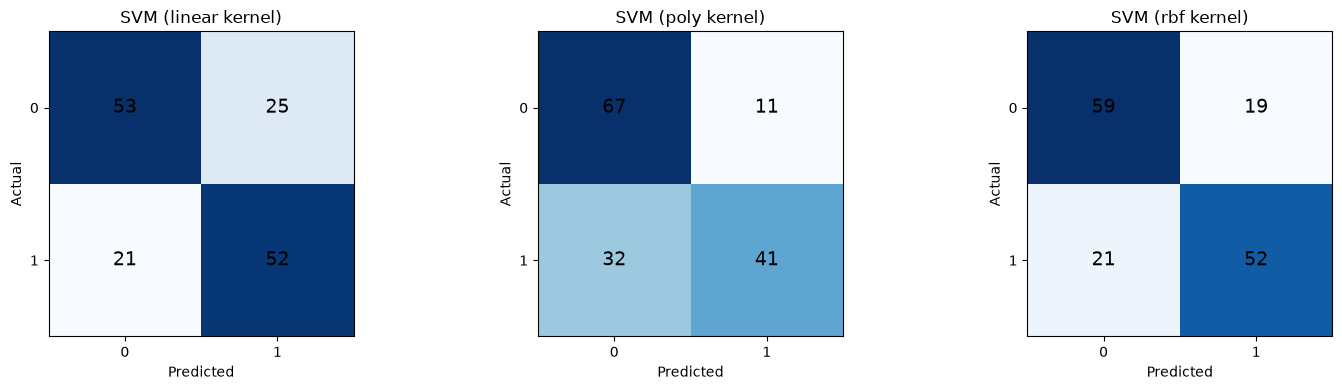

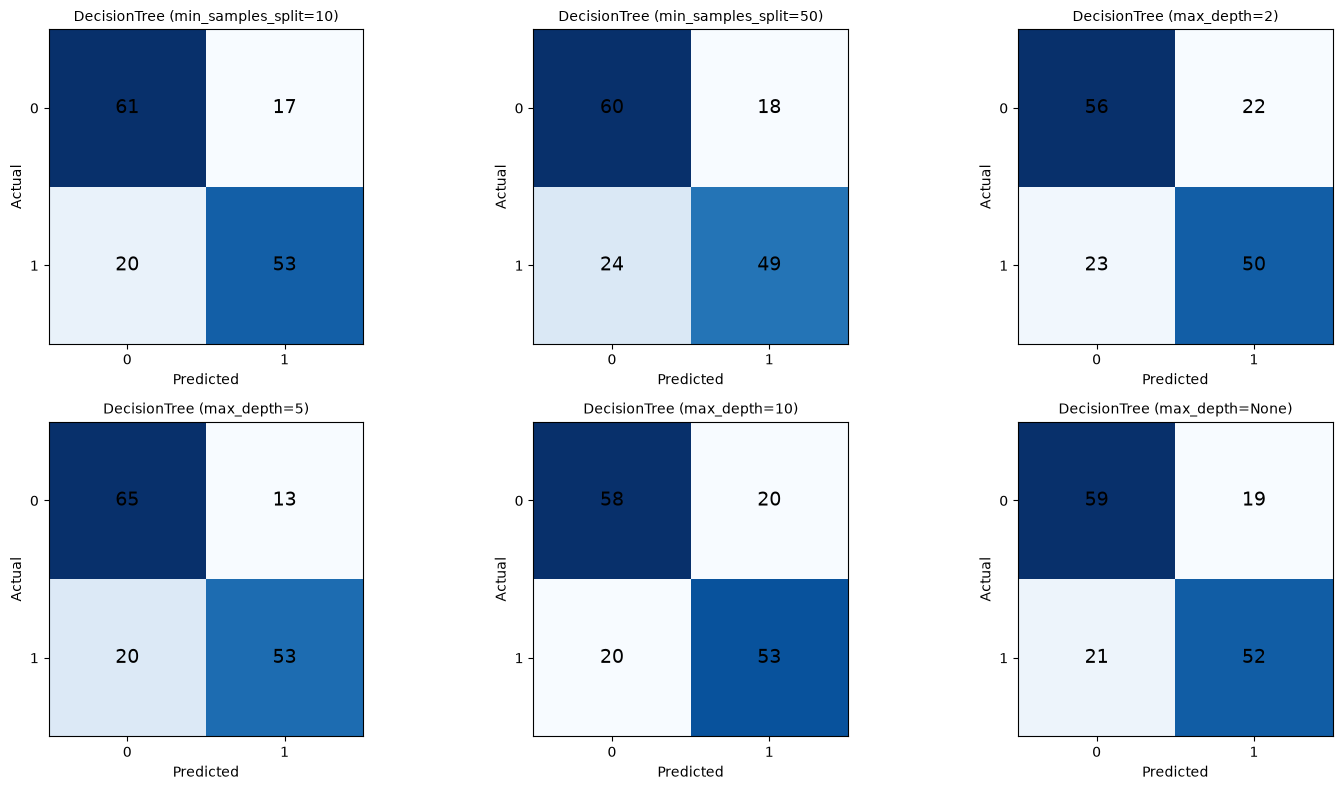

In [7]:
# Plot confusion matrices for SVM
svm_names = [name for name in all_cms if name.startswith("SVM")]

fig, axes = plt.subplots(1, len(svm_names), figsize=(5 * len(svm_names), 4))

for ax, name in zip(axes, svm_names):
    cm = all_cms[name]
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)

plt.tight_layout()
plt.savefig("svm_confusion_matrices.png", dpi=150)
plt.show()


# Plot confusion matrices for Decision Tree
dt_names = [name for name in all_cms if name.startswith("DecisionTree")]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, name in zip(axes, dt_names):
    cm = all_cms[name]
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)

plt.tight_layout()
plt.savefig("tree_confusion_matrices.png", dpi=150)
plt.show()

In [8]:
results_df = pd.DataFrame(results)
results_df.to_csv("results_summary.csv", index=False)
results_df

,model,accuracy,precision,recall,f1_score,train_time_sec,train_cpu_sec,train_mem_mb,predict_time_sec
0,SVM (linear kernel),0.695364,0.675325,0.712329,0.693333,0.028007,0.014063,0.175781,0.011453
1,SVM (poly kernel),0.715232,0.788462,0.561644,0.656000,0.013618,0.012500,0.000000,0.002995
2,SVM (rbf kernel),0.735099,0.732394,0.712329,0.722222,0.015291,0.015625,0.000000,0.006304
3,DecisionTree (min_samples_split=10),0.754967,0.757143,0.726027,0.741259,0.006275,0.006250,0.148438,0.001081
4,DecisionTree (min_samples_split=50),0.721854,0.731343,0.671233,0.700000,0.005000,0.004687,0.000000,0.002006
5,DecisionTree (max_depth=2),0.701987,0.694444,0.684932,0.689655,0.005713,0.003906,0.000000,0.001091
6,DecisionTree (max_depth=5),0.781457,0.803030,0.726027,0.762590,0.004717,0.005469,0.000000,0.002002
7,DecisionTree (max_depth=10),0.735099,0.726027,0.726027,0.726027,0.006870,0.004687,0.000000,0.001073
8,DecisionTree (max_depth=None),0.735099,0.732394,0.712329,0.722222,0.006490,0.006250,0.000000,0.001109


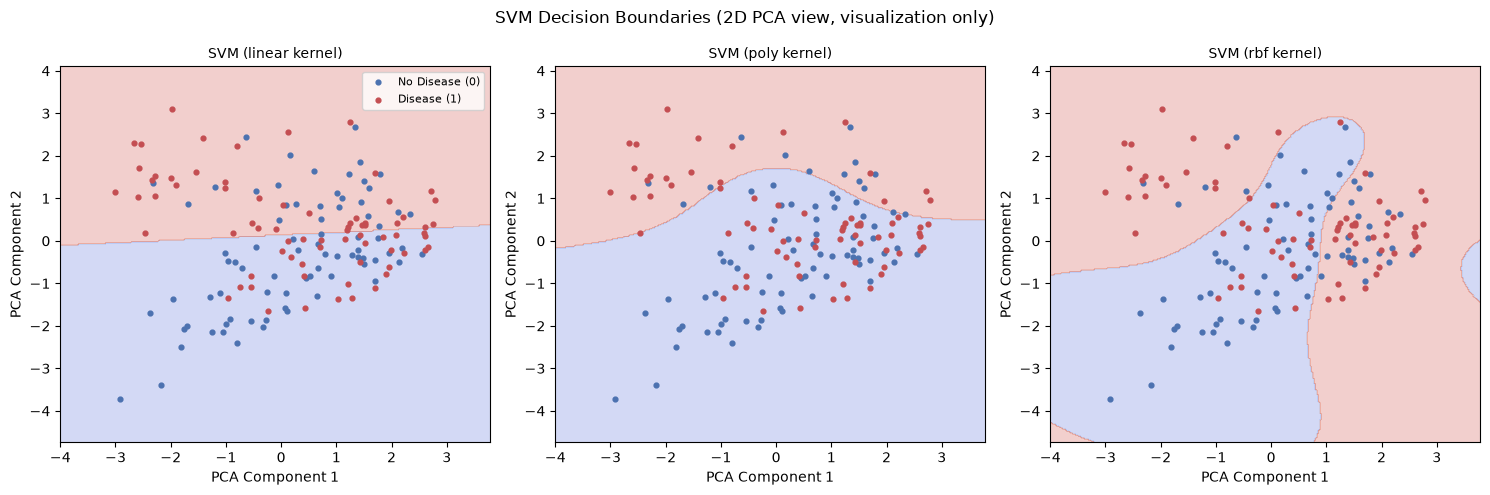

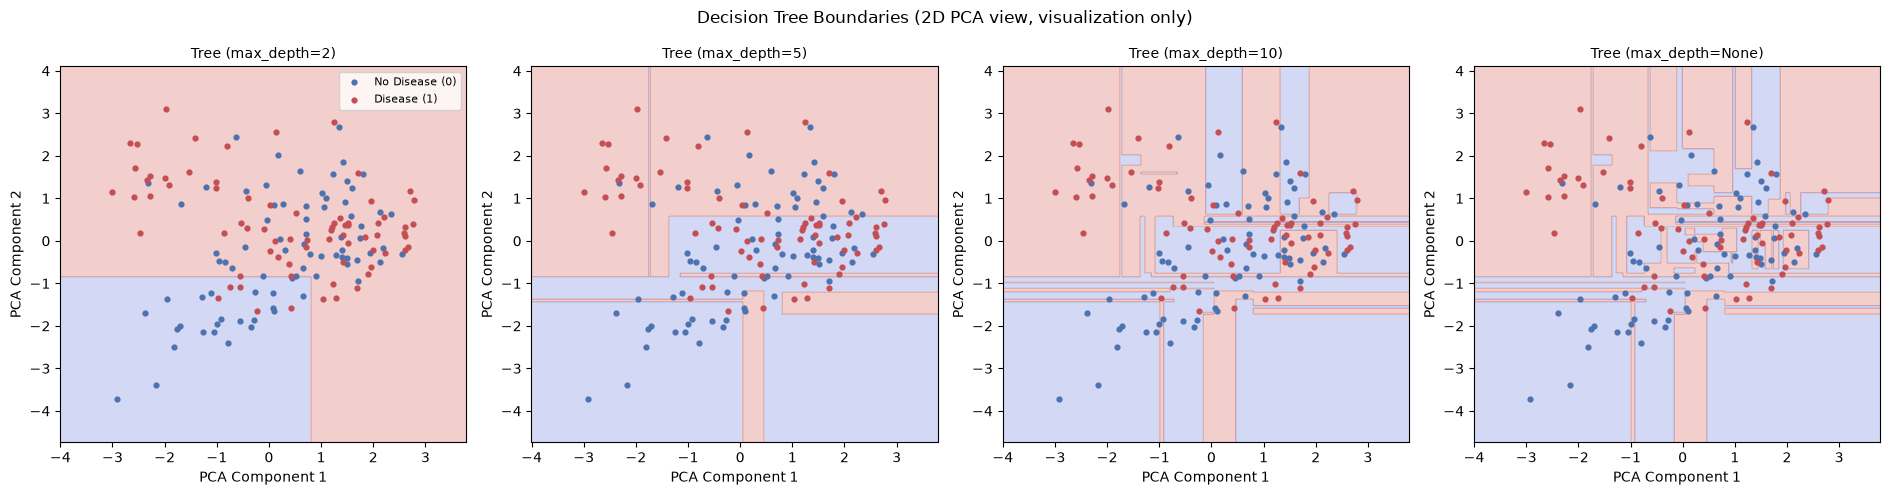

In [9]:
# Reduce to 2D for visualization only
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

def plot_decision_boundary(ax, model, X2d, y2d, title):
    x_min, x_max = X2d[:, 0].min() - 1, X2d[:, 0].max() + 1
    y_min, y_max = X2d[:, 1].min() - 1, X2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.scatter(X2d[y2d == 0, 0], X2d[y2d == 0, 1], c="#4C72B0", s=12, label="No Disease (0)")
    ax.scatter(X2d[y2d == 1, 0], X2d[y2d == 1, 1], c="#C44E52", s=12, label="Disease (1)")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("PCA Component 1"); ax.set_ylabel("PCA Component 2")

# SVM boundaries
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, kernel in zip(axes, svm_kernels):
    m = SVC(kernel=kernel, random_state=RANDOM_STATE).fit(X_train_pca, y_train)
    plot_decision_boundary(ax, m, X_test_pca, y_test.values, f"SVM ({kernel} kernel)")
axes[0].legend(fontsize=8)
plt.suptitle("SVM Decision Boundaries (2D PCA view, visualization only)")
plt.tight_layout()
plt.savefig("svm_decision_boundaries.png", dpi=150, bbox_inches="tight")
plt.show()

# Decision Tree boundaries
depths = [2, 5, 10, None]
fig, axes = plt.subplots(1, 4, figsize=(19, 5))
for ax, depth in zip(axes, depths):
    m = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE).fit(X_train_pca, y_train)
    plot_decision_boundary(ax, m, X_test_pca, y_test.values, f"Tree (max_depth={depth})")
axes[0].legend(fontsize=8)
plt.suptitle("Decision Tree Boundaries (2D PCA view, visualization only)")
plt.tight_layout()
plt.savefig("tree_decision_boundaries.png", dpi=150, bbox_inches="tight")
plt.show()

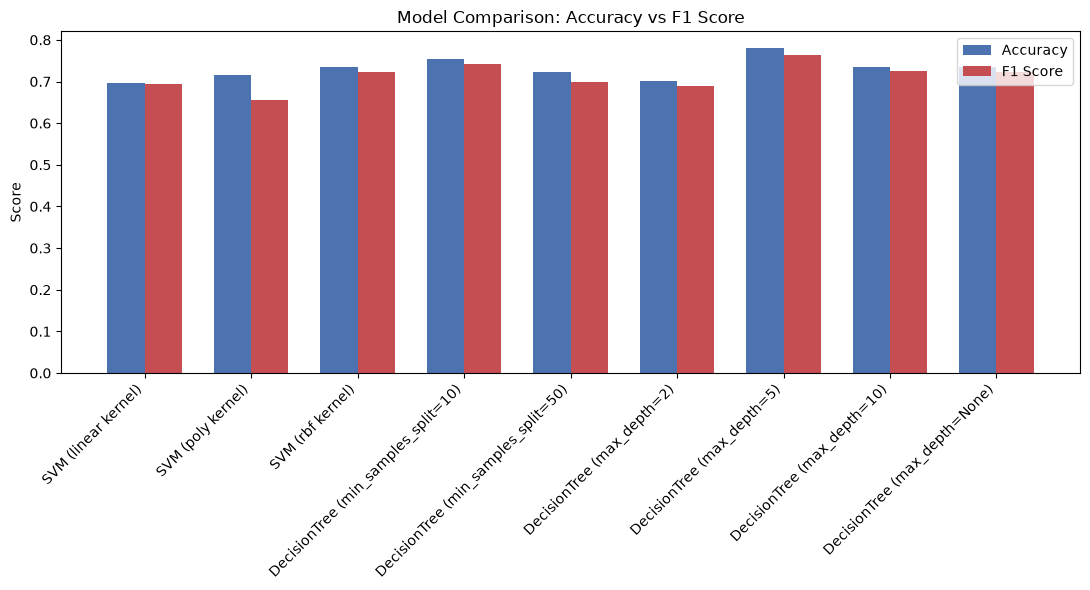

In [10]:
# Bar chart: Accuracy vs F1 for every model
x = np.arange(len(results_df))   # one position per model: 0, 1, 2, ...
width = 0.35                     # thickness of each bar

plt.figure(figsize=(11, 6))
plt.bar(x - width/2, results_df["accuracy"], width, label="Accuracy", color="#4C72B0")
plt.bar(x + width/2, results_df["f1_score"], width, label="F1 Score", color="#C44E52")

plt.xticks(x, results_df["model"], rotation=45, ha="right")
plt.ylabel("Score")
plt.title("Model Comparison: Accuracy vs F1 Score")
plt.legend()
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300)
plt.show()